### **Get tensors**

In [1]:
import torch
from torch.utils.data import DataLoader
from scripts.models import SWEUNet
from scripts.utils import CachedDataset
import pandas as pd
import patcher
import torch.nn.functional as F

work_hw = [177, 717]
def _resize(x):                              # [N, C, H, W] -> work grid
    if x.shape[-2:] == work_hw:
        return x
    # align_corners=True: node-registered grids. With work_hw = (4*Hi-3, 4*Wi-3) every INM
    # node lands EXACTLY on its ERA node (INM[i] == ERA[4i]); the 3 nodes per gap are blended.
    return F.interpolate(x, size=work_hw, mode='bilinear', align_corners=True)

exp_name = 'exp2_fullres_RussiaCrop_T_flatten_E_meanstd'
ds_name = 'Contigous_Russia_Dataset'

pth = f'/Users/a1/Desktop/arpp/dborisov/database/cached/{ds_name}'
test_ds_cached  = CachedDataset(f'{pth}/test')
test_loader  = DataLoader(test_ds_cached,  batch_size=1, num_workers=4)

cfg = {
    'name': exp_name,
    # ---- model (read by SWEUNet) ----
    'work_hw':       [177, 717], #[180,720],#[361, 1440],   # full ERA grid; INM (91x360) is upsampled onto it
    'e_pooled':      True,          # cache holds (mean,std) over E -> skip runtime e_pool
    't_collapse':    'flatten',     # exp1 history collapse: fold the Ts window into channels
    'base':          16,#32,        # stem width; channels double each level
    'depth':         4,#5,          # 5 downsamples -> bottleneck ~12x45; keeps O(N^2) attn tractable
    'cond_dim':      32,            # FiLM conditioning width (lead + season)
    'n_freqs':       6,             # lead sinusoidal-encoding frequency count
    'max_lead_days': 120.0,         # leads span 0..112 d (17 weekly frames)
    'attn_heads':    4,             # bottleneck spatial self-attention heads
    # ---- training (splat into train(); see scripts/train.py) ----
    'train': {
        'epochs':        30,
        'lr':            3e-3,
        'weight_decay':  1e-4,
        'scheduler':     'cosine',
        'warmup_epochs': 5,
        'min_lr':        1e-6,
        'grad_clip':     1.0,
        'target_key':    'target_sd_log_17weeks',
        #'persist_key':   'hist_sd_log_6weeks',   # last obs anomaly -> persistence baseline
        'out_dir':       f'/Users/a1/Desktop/arpp/dborisov/experiments/{exp_name}',
        'save_weights':  'best'
    },
}

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
model = SWEUNet(cfg).to(device)
with torch.no_grad():                                        # materialize LazyConv2d stem BEFORE load
    model({k: v.to(device) for k, v in next(iter(test_loader)).items()})
state_dict = torch.load(f'{cfg["train"]["out_dir"]}/model_best.pt', map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

target_key = 'target_sd_log_17weeks'
inm_bbox = {'x0':180, 'y0':40, 'xSize':180, 'ySize':45}
era_bbox = {'x0':180*4, 'y0':40*4, 'xSize':(180*4)-3, 'ySize':(45*4)-3}

test_dates = pd.date_range('20240901', '20260201', freq='MS')
assert len(test_ds_cached) == len(test_dates), 'cache / test_dates length mismatch'

# preds & target are UNNORMALIZED log-anomalies (Dataset skips norm for target_sd) -> no *std here.
preds, trgts, masks, clim_reqs, inm_reqs = [], [], [], [], []
with torch.no_grad():
    for date, batch in zip(test_dates, test_loader):
        date_str = date.strftime('%Y%m%d')
        batch = {k: v.to(device) for k, v in batch.items()}
        preds.append(model(batch).squeeze(0).cpu())            # [17,H,W] log-anom
        trgts.append(batch[target_key].squeeze(0).cpu())       # [17,H,W] log-anom
        masks.append(batch[f'{target_key}_mask'].squeeze(0).cpu())  # [17,H,W] True = exclude
        # ERA target log-climate: era_bbox, tSize=17, xyStep=1, tStep=7
        clim_reqs.append(patcher.Request('sd_log', era_bbox['x0'], era_bbox['y0'], date_str,
                                         era_bbox['xSize'], era_bbox['ySize'], 17, 1, 7))
        # INM SWE fcst is a SHIFTED var -> request FULL width; roll+crop AFTER load
        inm_reqs.append(patcher.Request('inm_swe_log', 0, 0, date_str,
                                        360, 91, 17, 1, 7, date.month))

context = patcher.Context('/Volumes/portable/arpp/data', 16)

# --- ERA target & model forecast, reconstructed to SWE (mm): expm1(log_clim + log_anom) ---
era_clim_log = torch.stack(patcher.load_climate(context, clim_reqs))    # [N,17,177,717]
era  = torch.expm1(era_clim_log + torch.stack(trgts))                   # ground truth
pred = torch.expm1(era_clim_log + torch.stack(preds))                   # model forecast

# --- INM baseline (mm): ensemble-mean, roll 180 + crop (SHIFTED), then upsample to work grid ---
y0, y1 = inm_bbox['y0'], inm_bbox['y0'] + inm_bbox['ySize']
x0, x1 = inm_bbox['x0'], inm_bbox['x0'] + inm_bbox['xSize']
inm_anom_log = torch.stack([t.mean(0) for t in patcher.load(context, inm_reqs)])  # ens-mean, ragged-E safe
inm_anom_log = torch.roll(inm_anom_log, 180, dims=-1)[..., y0:y1, x0:x1]
inm_clim_log = torch.roll(torch.stack(patcher.load_climate(context, inm_reqs)), 180, dims=-1)[..., y0:y1, x0:x1]
inm = _resize(torch.expm1(inm_clim_log + inm_anom_log))                 # [N,17,177,717]

mask = torch.stack(masks)                                               # [N,17,177,717] True = exclude
print(era.shape, inm.shape, pred.shape, mask.shape)


torch.Size([18, 17, 177, 717]) torch.Size([18, 17, 177, 717]) torch.Size([18, 17, 177, 717]) torch.Size([18, 17, 177, 717])


In [2]:
import matplotlib.pyplot as plt
plt.ioff()   # inline backend + interactive=True double-displays EVERY figure. ioff -> a figure
             # shows only when we display() it (bind below, or nowhere -> for the HTML exporter).

# Plot fns RETURN a Figure (so the same fns feed both the notebook and the HTML exporter).
# bind renders one into a single Output, updating on any control change.
from ipywidgets import Output, VBox, HBox, SelectionSlider, Dropdown
from IPython.display import clear_output, display

def bind(plot_fn, controls):
    """controls: {name: widget}. Calls plot_fn(**{name: widget.value}) -> Figure on every change."""
    out = Output()
    def render(_=None):
        with out:
            clear_output(wait=True)              # replace previous figure -> never stacks
            fig = plot_fn(**{name: w.value for name, w in controls.items()})
            if fig is not None:
                display(fig); plt.close(fig)
    for w in controls.values():
        w.observe(render, names='value')
    render()                                     # initial draw
    display(VBox([HBox(list(controls.values())), out]))


### **SWE (mm) per test date per lead**

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# columns, in the requested order: INM | ERA | SWEUNet  (all [N,17,H,W] mm SWE from cell 0)
SOURCES = [('INM', inm), ('ERA', era), ('SWEUNet', pred)]
_CMAP = plt.get_cmap('Blues').copy()
_CMAP.set_bad('0.85')                                   # masked / dead cells -> light gray


def plot_forecast(date, fig_w=15):
    """(17,3) grid: rows = lead 0..16 weeks, cols = INM/ERA/SWEUNet, for one init date."""
    i = test_dates.get_loc(pd.Timestamp(date))
    m = mask[i].bool()                                  # [17,H,W]  True = exclude
    date0 = pd.Timestamp(date)

    H, W = era.shape[-2:]
    panel_h = (fig_w / 3) * (H / W)                     # equal-aspect panel height, inches
    fig_h = 17 * (panel_h + 0.22) + 0.3                 # + per-row title overhead

    fig, axes = plt.subplots(17, 3, figsize=(fig_w, fig_h), constrained_layout=True)
    fig.set_constrained_layout_pads(h_pad=0.01, w_pad=0.01, hspace=0.01, wspace=0.01)
    for L in range(17):
        planes = []
        for _, src in SOURCES:                          # mask -> NaN so cells drop out
            f = src[i, L].float().clone()
            f[m[L]] = float('nan')
            planes.append(f.numpy())
        finite = np.concatenate([p[np.isfinite(p)] for p in planes]) if planes else np.array([0.])
        vmax = np.nanpercentile(finite, 99) if finite.size else 1.0   # per-lead shared, robust
        vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
        for c, ((name, _), plane) in enumerate(zip(SOURCES, planes)):
            ax = axes[L, c]
            im = ax.imshow(plane, vmin=0, vmax=vmax, cmap=_CMAP, origin='lower')
            ax.set_title(f"{name} | {(date0 + pd.Timedelta(L, 'W')).strftime('%Y%m%d')}, lead {L} week",
                         fontsize=7, pad=2)
            ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=list(axes[L, :]), fraction=0.015, pad=0.01, label='SWE, mm')
    return fig


bind(plot_forecast, {'date': SelectionSlider(options=[(d.strftime('%Y-%m-%d'), d) for d in test_dates],
                                             description='init date', continuous_update=False)})


### **Metrics global per lead** 

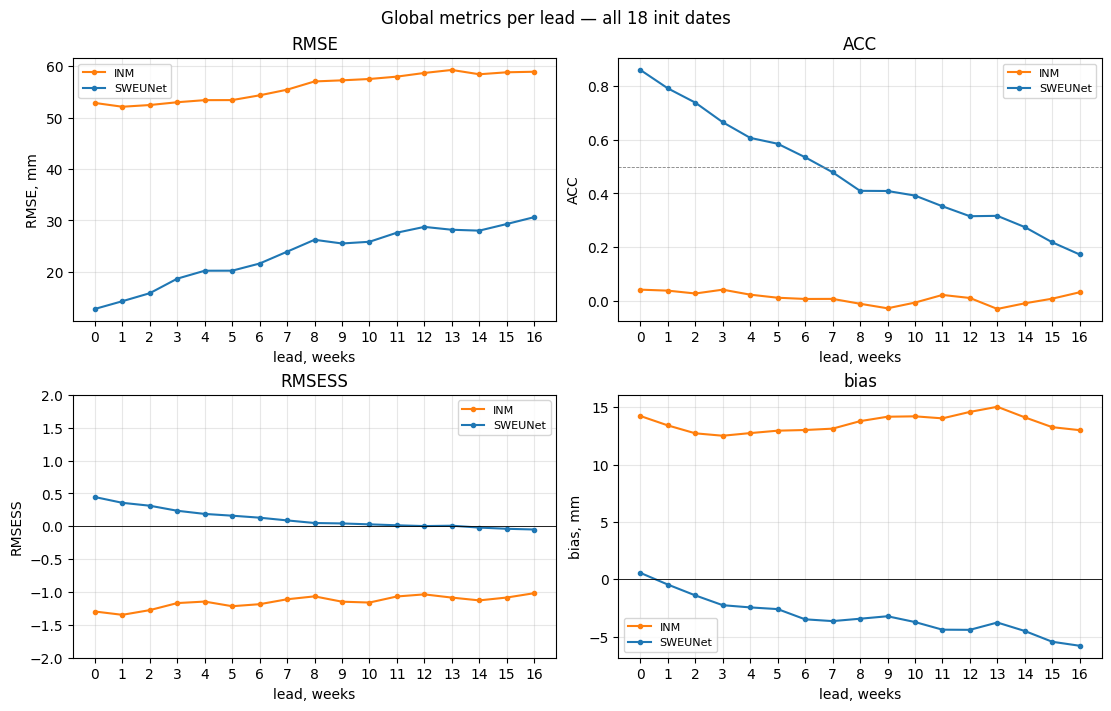

In [4]:
# Global (domain-aggregated) metrics vs lead time, in mm. Two forecasts: INM and SWEUNet (pred),
# both verified against ERA. ACC / RMSESS use mm anomalies about the ERA climatological-normal SWE.
LEADS = np.arange(17)                             # lead index -> "week L" (matches the map titles)
clim_ref = torch.expm1(era_clim_log)             # [N,17,H,W] climatological-normal SWE, mm
valid_all = ~mask.bool()                         # [N,17,H,W] True = keep

def per_lead_metrics(fc, obs, clim, valid):
    """RMSE / ACC / RMSESS / bias per lead, reducing over every axis except L (dim=-3).
    RMSESS = 1 - RMSE_model / RMSE_clim, RMSE_clim = RMS of the obs anomaly (climatology fcst).
    bias = mean(fc - obs): >0 = forecast too high. NaN where a lead has no valid cells."""
    err       = fc - obs
    fa, oa    = fc - clim, obs - clim            # anomalies about the verifying climatology
    w         = valid.float()
    dims      = tuple(d for d in range(fc.ndim) if d != fc.ndim - 3)
    swr       = w.sum(dims)
    sw        = swr.clamp_min(1e-8)
    ok        = swr > 0
    fin       = lambda x: torch.where(ok, x, torch.tensor(float('nan')))
    rmse      = torch.sqrt((w * err ** 2).sum(dims) / sw)
    rmse_clim = torch.sqrt((w * oa ** 2).sum(dims) / sw)     # = RMSE of the climatology forecast
    return {
        'RMSE':   fin(rmse),
        'ACC':    fin((w * fa * oa).sum(dims) /
                      torch.sqrt((w * fa * fa).sum(dims) * (w * oa * oa).sum(dims)).clamp_min(1e-8)),
        'RMSESS': fin(1 - rmse / rmse_clim.clamp_min(1e-8)),
        'bias':   fin((w * err).sum(dims) / sw),
    }

_ORDER = ['RMSE', 'ACC', 'RMSESS', 'bias']
_YLAB  = {'RMSE': 'RMSE, mm', 'ACC': 'ACC', 'RMSESS': 'RMSESS', 'bias': 'bias, mm'}

def _plot_grid(m_inm, m_pred, suptitle, xdates=None):
    """xdates: per-lead valid Timestamps -> label x by date; None -> label by lead week."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    for ax, name in zip(axes.flat, _ORDER):
        ax.plot(LEADS, m_inm[name].numpy(),  '-o', ms=3, color='tab:orange', label='INM')
        ax.plot(LEADS, m_pred[name].numpy(), '-o', ms=3, color='tab:blue',   label='SWEUNet')
        ax.set_title(name); ax.set_ylabel(_YLAB[name])
        ax.set_xticks(LEADS); ax.grid(alpha=0.3); ax.legend(fontsize=8)
        if xdates is not None:
            ax.set_xticklabels([d.strftime('%m-%d') for d in xdates], rotation=45, ha='right', fontsize=6)
            ax.set_xlabel('valid date')
        else:
            ax.set_xlabel('lead, weeks')
        if name in ('bias', 'RMSESS'): ax.axhline(0, color='k', lw=0.6)   # RMSESS 0 = climatology
        if name == 'ACC':              ax.axhline(0.5, color='grey', ls='--', lw=0.6)  # useful-skill
        if name == 'RMSESS':           ax.set_ylim(-2, 2)
    fig.suptitle(suptitle)
    return fig

# --- total: over all init dates (seasonal-average performance); x = lead weeks ---
_tot = _plot_grid(per_lead_metrics(inm,  era, clim_ref, valid_all),
                  per_lead_metrics(pred, era, clim_ref, valid_all),
                  f'Global metrics per lead — all {len(test_dates)} init dates')
display(_tot); plt.close(_tot)

# --- per init date, scrollable; x = valid date of each lead ---
def plot_metrics_date(date):
    i = test_dates.get_loc(pd.Timestamp(date))
    date0 = pd.Timestamp(date)
    xdates = [date0 + pd.Timedelta(L, 'W') for L in LEADS]        # valid time = t0 + L weeks
    return _plot_grid(per_lead_metrics(inm[i],  era[i], clim_ref[i], valid_all[i]),
                      per_lead_metrics(pred[i], era[i], clim_ref[i], valid_all[i]),
                      f'Global metrics per lead — init {date0:%Y-%m-%d}', xdates=xdates)

bind(plot_metrics_date, {'date': SelectionSlider(options=[(d.strftime('%Y-%m-%d'), d) for d in test_dates],
                                                 description='init date', continuous_update=False)})


### **Metrics heatmaps**

In [5]:
# Seasonal skill: metric as a heatmap of (init date x lead), per model + their difference.
from matplotlib.colors import TwoSlopeNorm

_CV = plt.get_cmap('viridis').copy(); _CV.set_bad('0.85')     # sequential (RMSE / bias)
_CD = plt.get_cmap('RdBu_r').copy();  _CD.set_bad('0.85')     # diff panel
_CS = plt.get_cmap('PRGn').copy();    _CS.set_bad('0.85')     # skill: green >0, purple <0
_DIVERGING = {'RMSESS', 'ACC'}                                # zero is the meaningful boundary

def spatial_metrics(fc, obs, clim, valid):
    """Metric per (init date, lead) -> [N,17]; reduces the spatial dims only."""
    err = fc - obs; fa, oa = fc - clim, obs - clim; w = valid.float()
    d = (-2, -1)
    swr = w.sum(d); sw = swr.clamp_min(1e-8); ok = swr > 0
    fin = lambda x: torch.where(ok, x, torch.tensor(float('nan')))
    rmse      = torch.sqrt((w * err ** 2).sum(d) / sw)
    rmse_clim = torch.sqrt((w * oa ** 2).sum(d) / sw)         # = RMSE of the climatology forecast
    return {
        'RMSE':   fin(rmse),
        'ACC':    fin((w * fa * oa).sum(d) /
                      torch.sqrt((w * fa * fa).sum(d) * (w * oa * oa).sum(d)).clamp_min(1e-8)),
        'RMSESS': fin(1 - rmse / rmse_clim.clamp_min(1e-8)),
        'bias':   fin((w * err).sum(d) / sw),
    }

_INM_GRID  = spatial_metrics(inm,  era, clim_ref, valid_all)   # each [N,17]
_PRED_GRID = spatial_metrics(pred, era, clim_ref, valid_all)
_YT = [d.strftime('%Y-%m') for d in test_dates]                # init-date row labels
_VMIN_FLOOR = {'RMSESS': -1.0, 'ACC': -1.0}                    # keep the informative range readable

def plot_skill_heatmap(metric='RMSESS'):
    A, B = _INM_GRID[metric].numpy(), _PRED_GRID[metric].numpy()   # [N,17]
    D = B - A                                                      # SWEUNet - INM
    vmin, vmax = np.nanmin([A, B]), np.nanmax([A, B])
    vmin = max(vmin, _VMIN_FLOOR.get(metric, vmin))
    dlim = np.nanmax(np.abs(D)) or 1.0
    diverging = metric in _DIVERGING

    if diverging:                                                 # hard color flip at 0 (+ contour)
        lo, hi = min(vmin, -1e-6), max(vmax, 1e-6)                # TwoSlopeNorm needs lo<0<hi
        ab = dict(cmap=_CS, norm=TwoSlopeNorm(vcenter=0.0, vmin=lo, vmax=hi))
    else:
        ab = dict(cmap=_CV, vmin=vmin, vmax=vmax)

    panels = [(A, 'INM', ab), (B, 'SWEUNet', ab),
              (D, 'SWEUNet − INM', dict(cmap=_CD, vmin=-dlim, vmax=dlim))]
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
    for ax, (M, ttl, kw) in zip(axes, panels):
        im = ax.imshow(M, aspect='auto', origin='upper', **kw)
        if diverging and ttl != 'SWEUNet − INM' and np.nanmin(M) < 0 < np.nanmax(M):
            ax.contour(M, levels=[0], colors='k', linewidths=0.7)   # sharp zero (skill) boundary
        ax.set_title(ttl); ax.set_xlabel('lead, weeks'); ax.set_xticks(LEADS)
        ax.set_yticks(range(len(_YT))); ax.set_yticklabels(_YT, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label=metric)
    better = {'ACC': '+ (red) = SWEUNet better', 'RMSESS': '+ (red) = SWEUNet better',
              'RMSE': '− (blue) = SWEUNet better', 'bias': 'sign = SWEUNet − INM bias'}[metric]
    fig.suptitle(f'{metric} by init date × lead     |     diff: {better}')
    return fig

bind(plot_skill_heatmap, {'metric': Dropdown(options=['RMSESS', 'ACC', 'RMSE', 'bias'],
                                             value='RMSESS', description='metric')})


### **Metrics spatial**

In [6]:
# Where does it miss? Per-cell metrics over dates, for a chosen lead ('all' = averaged over leads).
def cell_metrics(fc, obs, clim, valid, dims):
    """Per-cell metric -> [H,W]; `dims` says what to reduce (dates, or dates+leads)."""
    err = fc - obs; fa, oa = fc - clim, obs - clim; w = valid.float()
    swr = w.sum(dims); sw = swr.clamp_min(1e-8); ok = swr > 0
    fin = lambda x: torch.where(ok, x, torch.tensor(float('nan')))
    rmse      = torch.sqrt((w * err ** 2).sum(dims) / sw)
    rmse_clim = torch.sqrt((w * oa ** 2).sum(dims) / sw)
    return {
        'RMSE':   fin(rmse),
        'ACC':    fin((w * fa * oa).sum(dims) /
                      torch.sqrt((w * fa * fa).sum(dims) * (w * oa * oa).sum(dims)).clamp_min(1e-8)),
        'RMSESS': fin(1 - rmse / rmse_clim.clamp_min(1e-8)),
        'bias':   fin((w * err).sum(dims) / sw),
    }

def _cell_maps(fc, lead):
    if lead == 'all':                                          # reduce dates AND leads
        return cell_metrics(fc, era, clim_ref, valid_all, (0, 1))
    return cell_metrics(fc[:, lead], era[:, lead], clim_ref[:, lead], valid_all[:, lead], (0,))  # dates only

def plot_spatial_maps(model='SWEUNet', lead='all', fig_w=14):
    M = _cell_maps(pred if model == 'SWEUNet' else inm, lead)
    H, W = era.shape[-2:]
    fig_h = 2 * (fig_w / 2 * H / W) + 1.6
    fig, axes = plt.subplots(2, 2, figsize=(fig_w, fig_h), constrained_layout=True)
    for ax, name in zip(axes.flat, ['RMSE', 'RMSESS', 'ACC', 'bias']):
        arr = M[name].numpy()
        if name in _DIVERGING:                                 # RMSESS/ACC: green>0, purple<0, 0-contour
            lo = max(min(np.nanmin(arr), -1e-6), -1.0); hi = max(np.nanmax(arr), 1e-6)
            im = ax.imshow(arr, origin='lower', cmap=_CS, norm=TwoSlopeNorm(0., lo, hi))
            if np.nanmin(arr) < 0 < np.nanmax(arr):
                ax.contour(arr, levels=[0], colors='k', linewidths=0.6)
        elif name == 'bias':                                   # signed: symmetric diverging about 0
            lim = np.nanmax(np.abs(arr)) or 1.0
            im = ax.imshow(arr, origin='lower', cmap=_CD, vmin=-lim, vmax=lim)
        else:                                                  # RMSE: sequential (tracks snow magnitude)
            im = ax.imshow(arr, origin='lower', cmap=_CV)
        ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label=name)
    lead_txt = 'all leads' if lead == 'all' else f'lead {lead} week'
    fig.suptitle(f'{model}: per-cell metrics — {lead_txt}  (over {len(test_dates)} dates)')
    return fig

bind(plot_spatial_maps, {'model': Dropdown(options=['SWEUNet', 'INM'], description='model'),
                         'lead':  SelectionSlider(options=['all'] + list(range(17)), value='all',
                                                  description='lead', continuous_update=False)})


In [7]:
# Scrollable spatial ERROR maps (forecast − obs, mm) per lead: INM vs SWEUNet, one init date.
_CE = plt.get_cmap('RdBu_r').copy(); _CE.set_bad('0.85')     # +red = over-forecast, −blue = under

def plot_error_maps(date, fig_w=11):
    """(17,2) grid: rows = lead 0..16 weeks, cols = INM / SWEUNet signed error, one init date.
    Per-lead symmetric color scale shared across the two columns so they're comparable."""
    i = test_dates.get_loc(pd.Timestamp(date))
    m = mask[i].bool()                                       # [17,H,W] True = exclude
    date0 = pd.Timestamp(date)
    cols = [('INM err', inm[i] - era[i]), ('SWEUNet err', pred[i] - era[i])]   # each [17,H,W]

    H, W = era.shape[-2:]
    panel_h = (fig_w / 2) * (H / W)
    fig_h = 17 * (panel_h + 0.22) + 0.3
    fig, axes = plt.subplots(17, 2, figsize=(fig_w, fig_h), constrained_layout=True)
    fig.set_constrained_layout_pads(h_pad=0.01, w_pad=0.01, hspace=0.01, wspace=0.01)
    for L in range(17):
        planes = []
        for _, e in cols:
            f = e[L].float().clone(); f[m[L]] = float('nan'); planes.append(f.numpy())
        finite = np.concatenate([p[np.isfinite(p)] for p in planes]) if planes else np.array([0.])
        lim = np.nanpercentile(np.abs(finite), 99) if finite.size else 1.0    # symmetric, robust
        lim = lim if np.isfinite(lim) and lim > 0 else 1.0
        for c, ((nm, _), plane) in enumerate(zip(cols, planes)):
            ax = axes[L, c]
            im = ax.imshow(plane, origin='lower', cmap=_CE, vmin=-lim, vmax=lim)
            ax.set_title(f"{nm} | {(date0 + pd.Timedelta(L, 'W')):%Y%m%d}, lead {L} week", fontsize=7, pad=2)
            ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=list(axes[L, :]), fraction=0.015, pad=0.01, label='fcst − obs, mm')
    return fig

bind(plot_error_maps, {'date': SelectionSlider(options=[(d.strftime('%Y-%m-%d'), d) for d in test_dates],
                                               description='init date', continuous_update=False)})


In [8]:
# Export each viewer to a self-contained HTML (PNG frames + a JS slider). Opens in any browser,
# offline, no kernel/notebook needed -> share with colleagues.
import io, base64, json, os

OUT_DIR = f'/Users/a1/Desktop/arpp/dborisov/experiments/{exp_name}/results'
os.makedirs(OUT_DIR, exist_ok=True)

def export_scrollable(plot_fn, options, filename, title='frame', dpi=85):
    """options: [(label, value), ...]; plot_fn(value) -> Figure. Writes OUT_DIR/filename."""
    frames = []
    for label, val in options:
        fig = plot_fn(val)
        buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight'); plt.close(fig)
        frames.append({'label': str(label),
                       'src': 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()})
    html = f"""<!doctype html><meta charset=utf-8><title>{title}</title>
<style>body{{font-family:sans-serif;margin:1rem}} img{{max-width:100%;height:auto}} #s{{width:100%}}</style>
<div style="margin-bottom:.4rem">{title}: <b id=l></b></div>
<input id=s type=range min=0 max={len(frames) - 1} value=0>
<div><img id=i></div>
<script>const F={json.dumps(frames)},s=document.getElementById('s'),i=document.getElementById('i'),l=document.getElementById('l');
function u(){{i.src=F[s.value].src;l.textContent=F[s.value].label}}s.oninput=u;u()</script>"""
    path = os.path.join(OUT_DIR, filename)
    with open(path, 'w') as f: f.write(html)
    print(f'wrote {path}  ({len(frames)} frames, {os.path.getsize(path)/1024**2:.1f} MB)')

DATES    = [(d.strftime('%Y-%m-%d'), d) for d in test_dates]
METRICS  = [(m, m) for m in ['RMSESS', 'ACC', 'RMSE', 'bias']]
LEADOPTS = [('all leads', 'all')] + [(f'lead {L} week', L) for L in range(17)]

export_scrollable(plot_forecast,      DATES,   'swe_maps.html',        title='init date', dpi=150)
export_scrollable(plot_error_maps,    DATES,   'error_maps.html',      title='init date', dpi=150)
export_scrollable(plot_metrics_date,  DATES,   'metrics_by_date.html', title='init date', dpi=150)
export_scrollable(plot_skill_heatmap, METRICS, 'skill_heatmaps.html',  title='metric',    dpi=150)
for mdl in ['SWEUNet', 'INM']:
    export_scrollable(lambda lead, m=mdl: plot_spatial_maps(m, lead), LEADOPTS,
                      f'spatial_{mdl}.html', title='lead', dpi=110)


wrote /Users/a1/Desktop/arpp/dborisov/experiments/exp2_fullres_RussiaCrop_T_flatten_E_meanstd/results/swe_maps.html  (18 frames, 90.4 MB)
wrote /Users/a1/Desktop/arpp/dborisov/experiments/exp2_fullres_RussiaCrop_T_flatten_E_meanstd/results/error_maps.html  (18 frames, 85.2 MB)
wrote /Users/a1/Desktop/arpp/dborisov/experiments/exp2_fullres_RussiaCrop_T_flatten_E_meanstd/results/metrics_by_date.html  (18 frames, 3.4 MB)
wrote /Users/a1/Desktop/arpp/dborisov/experiments/exp2_fullres_RussiaCrop_T_flatten_E_meanstd/results/skill_heatmaps.html  (4 frames, 0.6 MB)
wrote /Users/a1/Desktop/arpp/dborisov/experiments/exp2_fullres_RussiaCrop_T_flatten_E_meanstd/results/spatial_SWEUNet.html  (18 frames, 12.7 MB)
wrote /Users/a1/Desktop/arpp/dborisov/experiments/exp2_fullres_RussiaCrop_T_flatten_E_meanstd/results/spatial_INM.html  (18 frames, 11.1 MB)
